In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from asyncssh import forward
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import re
import copy

Data prep

In [2]:
data=pd.read_csv('../Database/Dataset_medoids_20n.csv')

# tokens - top_time model
vocab_top = ['-p', '+p', '-l', '+l', 'd']
vocab_seq = ['1', '2', '3', '4']
vocab = {}
token_id = 0

for t in vocab_top:
    for s in vocab_seq:
        fused = f'{t}_{s}'
        vocab[fused] = token_id
        token_id += 1


def tokenize_sequence(token, vocab):
    tokenized = []
    for i in range(3):  # Since sequences are exactly length 3
        fused_key = token[i]
        tokenized.append(vocab[fused_key])
    return tokenized


# Tokenize data
data['splited_top'] = data['top'].apply(lambda text: re.findall(r'[+-][pl]|d', str(text)))
data['splited_seq'] = data['seq'].apply(lambda text: re.findall(r'1|2|3|4', str(text)))

data['tokens'] = data.apply(lambda row: [f'{top}_{seq}' for top, seq in zip(row['splited_top'], row['splited_seq'])],
                            axis=1)
data['tokenased'] = data.apply(lambda row: tokenize_sequence(row['tokens'], vocab), axis=1)
data=data.drop(['top','seq','tokens', 'splited_top', 'splited_seq'], axis=1)
#data=data[data['sredni_czas']<1000000]
#data=data[data['sredni_czas']>0]

# 1. Filter out the 1M cap values first
#df_filtered = data[data['sredni_czas'] < 1000000].copy()
df_filtered=data.copy()

# 2. Calculate the baseline math
Y_MEAN = df_filtered['sredni_czas'].mean()
Y_STD = df_filtered['sredni_czas'].std()

# 3. Create a normalized column for PyTorch to learn
df_filtered['time_normalized'] = (df_filtered['sredni_czas'] - Y_MEAN) / Y_STD
#data['time_normal']=df_filtered['time_normalized']
#data=data.dropna()
print(data)

         b1_sin    g1_sin    d1_sin    e1_sin    z1_sin    a2_sin    b2_sin  \
0     -0.791544  0.968060  0.580845 -0.119964 -0.993211 -0.918239  0.414534   
1     -0.458650  0.996478  0.669520 -0.102098 -0.976785 -0.924346  0.241244   
2     -0.765596  0.978148  0.626196 -0.266229 -0.968583 -0.947154  0.224781   
3     -0.777585  0.975955  0.645724 -0.218825 -0.998049 -0.924280  0.220187   
4     -0.270600  0.959658  0.612217 -0.389445 -0.946368 -0.996862  0.136061   
...         ...       ...       ...       ...       ...       ...       ...   
25321 -0.917824  0.984989  0.527401 -0.284015 -0.983414 -0.997859  0.991671   
25322 -0.922875  0.988652  0.505281 -0.288029 -0.996637 -0.978039  0.944606   
25323 -0.513391  0.961980  0.645324 -0.403386 -0.486488 -0.385101  0.505582   
25324 -0.749187  0.946705  0.996945 -0.795473 -0.942816 -0.929841  0.435074   
25325 -0.791010 -0.513841  0.749880 -0.380586 -0.946029 -0.983064  0.428304   

         g2_sin    d2_sin    e2_sin  ...  DT11_cos 

Tensors

In [20]:
# podział na set - stary
#X_df=data.drop(['sredni_czas','time_normal'], axis=1)
# Y - set because testing
#Y_df=data['sredni_czas']
#Y_df=data['time_normal']

#Y_df=np.log1p(Y_df) # making it ln (1+x)
#Y_df=Y_df/1000000
#X_temp, X_test, Y_temp, Y_test = train_test_split(X_df, Y_df, test_size=0.0833, random_state=42)
#X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.176, random_state=42)
# ---------------------------------------------------------------------------------------------------------------------------------------------------
# podział na set nowy
train, test = train_test_split(data, test_size=0.01)
test_fin = data[data['tokenased'].isin(test['tokenased'])].reset_index(drop=True)
train_fin = train[~train['tokenased'].isin(test_fin['tokenased'])].reset_index(drop=True)

X_test=test_fin.drop(['sredni_czas'], axis=1)
Y_test=test_fin['sredni_czas']

train_set, val_set = train_test_split(train_fin, test_size=0.1)
X_train = train_set.drop(['sredni_czas'], axis=1)
X_val = val_set.drop(['sredni_czas'], axis=1)
Y_train = train_set['sredni_czas']
Y_val = val_set['sredni_czas']

# Tensory Y
Y_train_ten=torch.tensor(Y_train.to_numpy(), dtype=torch.float)
Y_val_ten=torch.tensor(Y_val.to_numpy(), dtype=torch.float)
Y_test_ten=torch.tensor(Y_test.to_numpy(), dtype=torch.float)

# przygotowanie danych wejściowych dla modelu token --> time
X_train_tok=X_train['tokenased']
X_val_tok=X_val['tokenased']
X_test_tok=X_test['tokenased']

# przygotowanie danych wejciowych dla modelu kąt --> time
X_train_ang=X_train.drop(['tokenased'], axis=1)
X_val_ang=X_val.drop(['tokenased'], axis=1)
X_test_ang=X_test.drop(['tokenased'], axis=1)

batch=32

# Tensory wejściowe token --> time
X_ten_train_tok=torch.tensor(X_train_tok.tolist(), dtype=torch.long)
X_ten_val_tok=torch.tensor(X_val_tok.tolist(), dtype=torch.long)
X_ten_test_tok=torch.tensor(X_test_tok.tolist(), dtype=torch.long)


# Tensory wejściowe kat --> time
X_ten_train_ang=torch.tensor(X_train_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_val_ang=torch.tensor(X_val_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_test_ang=torch.tensor(X_test_ang.astype('float32').to_numpy(), dtype=torch.float)

# jednen dataset i dataloader dla połączonego modelu
train_ds_comb=TensorDataset(X_ten_train_tok, X_ten_train_ang, Y_train_ten)
train_loader_comb=DataLoader(train_ds_comb, batch_size=batch, shuffle=True)
val_ds_comb=TensorDataset(X_ten_val_tok, X_ten_val_ang, Y_val_ten)
val_loader_comb=DataLoader(val_ds_comb, batch_size=batch, shuffle=True)
#test_ds_comb=TensorDataset(X_ten_test_tok, X_ten_test_ang, Y_test)
#test_loader_comb=DataLoader(test_ds_comb, batch_size=batch, shuffle=False)

Utworzenie modelu

In [22]:
def censored_mse_loss(predictions, targets, cap_value=1000000.0):
    # Calculate standard squared error
    squared_errors = (predictions - targets) ** 2

    # Find where the dataset hit the artificial cap
    capped_mask = (targets >= cap_value)

    # Find where the model correctly guessed it would live longer than the cap
    over_predicted_mask = capped_mask & (predictions > targets)

    # If the simulation stopped at 1M, and the model guessed > 1M, set the error to 0
    squared_errors[over_predicted_mask] = 0.0

    return squared_errors.mean()


# tego nie tykać bo już jest wytrnowany
class GQuadTimeToken(nn.Module):
    def __init__(self, vocab_size=20, embedding_dim=6, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        flattened_size = 3 * embedding_dim
        self.fc1 = nn.Linear(flattened_size, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(p=0.15)
        self.fc4 = nn.Linear(32, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        x = embedded.view(embedded.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        Model_A_out = x
        return Model_A_out

# tu moge zmieniać ile chce
class GQuadTimeAng(nn.Module):
    def __init__(self):
        super(GQuadTimeAng, self).__init__()
        self.fc1=nn.Linear(306, 256)
        self.fc4=nn.Linear(256,128)
        self.fc2=nn.Linear(128, 64)
        self.fc3=nn.Linear(64, 32)


        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.2)
        self.bn1=nn.BatchNorm1d(128)


    def forward(self, x):
        x=self.re(self.fc1(x))
        x=self.re(self.fc4(x))
        x=self.re(self.fc2(x))
        x=self.drop(x)
        x=self.fc3(x)
        Model_B_out=x
        return Model_B_out

class GQuadComb(nn.Module):
    def __init__(self, model_a, model_b):
        super(GQuadComb, self).__init__()
        self.model_a = model_a
        self.model_b = model_b

        self.bnA=nn.BatchNorm1d(8)
        self.bnB=nn.BatchNorm1d(32)

        for param in self.model_a.parameters():
            param.requires_grad = False

        self.endmodel=nn.Sequential(
            nn.Linear(40, 32),
            nn.ReLU(),
            #nn.Dropout(p=0.25),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1),
        )
    def forward(self, input_a, input_b):
        out_a = self.model_a(input_a)
        out_b = self.model_b(input_b)
        out_a = self.bnA(out_a)
        out_b = self.bnB(out_b)

        com_input = torch.cat((out_a, out_b), 1)
        output = self.endmodel(com_input)
        return output

model_a = GQuadTimeToken()
model_a.load_state_dict(torch.load('../modele - wytrenowane/model_toptime_good.pth'))
model_b = GQuadTimeAng()
model_fin=GQuadComb(model_a, model_b)

trainable_parameters = filter(lambda p: p.requires_grad, model_fin.parameters())
#trainable_parameters = model_fin.parameters()
optimizer = torch.optim.Adam(trainable_parameters, lr=0.000075, weight_decay=2.5e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
criterion = nn.MSELoss()
#criterion = nn.HuberLoss(delta=1.0)

epochs = 1000
best_val_loss = float('inf')
how_many=25
counter_dd=0
best_so_far=None
training_loss=[]
val_los=[]
epoch_data=[]

for epoch in range(epochs):
    model_fin.train()
    epoch_train_loss = 0
    epoch_data.append(epoch)
    for batch_X_a, batch_X_b, batch_Y in train_loader_comb:
        optimizer.zero_grad()
        prediction = model_fin(batch_X_a, batch_X_b)
        loss = criterion(prediction, batch_Y.float().unsqueeze(1)) # loss for normal model
        #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
        loss.backward()
        optimizer.step()
        epoch_train_loss+=loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader_comb)
    training_loss.append(avg_train_loss)

    model_fin.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X_a, batch_X_b, batch_Y in val_loader_comb:
            prediction = model_fin(batch_X_a, batch_X_b)
            loss = criterion(prediction, batch_Y.float().unsqueeze(1)) # normal model
            #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
            val_loss+=loss.item()


    avg_val_loss = val_loss / len(val_loader_comb)
    scheduler.step(avg_val_loss)
    val_los.append(avg_val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter_dd = 0
        best_so_far=copy.deepcopy(model_fin.state_dict())
    else:
        counter_dd += 1

    if epoch %5 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if counter_dd >= how_many:
        print("Early Stopping")
        best_val_loss = np.sqrt(best_val_loss)
        #print(f'Średni błąd Validacji: {best_val_loss:.4f}')
        break

data_graph=pd.DataFrame({
    'Epoch': epoch_data,
    'Training Loss': training_loss,
    'Validation Loss': val_los
} )
model_fin.load_state_dict(best_so_far)


Epoch 000 | Train Loss: 207643493302.6075 | Val Loss: 220846347853.5757
Epoch 005 | Train Loss: 207036501554.6758 | Val Loss: 213325645389.5757
Epoch 010 | Train Loss: 203496322841.3379 | Val Loss: 205654935130.1818
Epoch 015 | Train Loss: 195294506267.0853 | Val Loss: 198778400519.7576
Epoch 020 | Train Loss: 179646650256.1638 | Val Loss: 183425352548.8485
Epoch 025 | Train Loss: 155270667840.6553 | Val Loss: 155472649479.7576
Epoch 030 | Train Loss: 122186194985.9386 | Val Loss: 119556599094.3030
Epoch 035 | Train Loss: 83464205166.9625 | Val Loss: 84216684916.3636
Epoch 040 | Train Loss: 46618023524.4778 | Val Loss: 44919332336.4848
Epoch 045 | Train Loss: 20920830663.8635 | Val Loss: 14559301220.8485
Epoch 050 | Train Loss: 10556430986.3754 | Val Loss: 7349355741.0909
Epoch 055 | Train Loss: 7579494998.9352 | Val Loss: 2905983761.4545
Epoch 060 | Train Loss: 7163179193.8840 | Val Loss: 2894075154.4242
Epoch 065 | Train Loss: 6591629790.3618 | Val Loss: 2403678178.9091
Epoch 070 | T

<All keys matched successfully>

Model test - i hope it works

--- FINAL EXAM RESULTS ---
On average, the model is off by: 125329.15 time units
R-squared Score (Accuracy proxy): 0.68


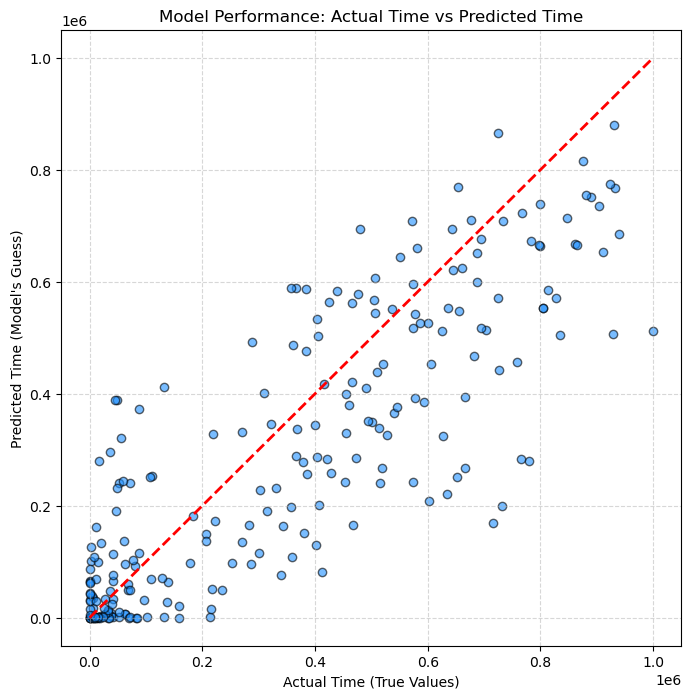

In [23]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_tok, X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()
df_preds=pd.DataFrame({
    'Tokens': [tuple(x) for x in X_ten_test_tok.numpy()],
    'Predictions':preds.flatten(),
    'Actuals':actuals.flatten()
})

zest=df_preds.groupby(['Tokens']).agg(
    avg_preds=('Predictions','mean'),
    actuals=('Actuals','mean')
)

preds=zest['avg_preds']
actuals=zest['actuals']

#preds = (preds * Y_STD) + Y_MEAN
#actuals = (actuals * Y_STD) + Y_MEAN

#actuals = 1000000 * actuals
#preds = 1000000 * preds

# if using np.log1p()
#actuals=np.expm1(actuals)
#preds=np.expm1(preds)

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [16]:
print(f"Epochs: {len(epoch_data)}, Train: {len(training_loss)}, Val: {len(val_los)}")

Epochs: 306, Train: 306, Val: 306


Graf train loss vs validation loss

In [1]:
data_graph=data_graph.iloc[5:].reset_index(drop=True)

# Replace these with your actual lists of loss values
epochs = data_graph['Epoch'] # Assuming 15 epochs
train_loss = data_graph['Training Loss']
val_loss = data_graph['Validation Loss']

plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(epochs, train_loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='red', marker='s')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Add the legend
plt.legend(loc='best', fontsize=12)

# Display the graph
plt.tight_layout()
plt.show()

NameError: name 'data_graph' is not defined

In [7]:
print(X_test)

        b1_sin    g1_sin    d1_sin    e1_sin    z1_sin    a2_sin    b2_sin  \
0    -0.511743  0.939274  0.627555 -0.396347 -0.989726 -0.945291  0.226311   
1    -0.519221  0.950516  0.669520 -0.692395 -0.937949 -0.812389  0.288865   
2    -0.515038  0.942408  0.576147 -0.234294 -0.980409 -0.991850 -0.049896   
3    -0.755625  0.980819  0.506937 -0.566262 -0.897566 -0.972043  0.373797   
4    -0.668352  0.910539  0.604182 -0.307191 -0.959018 -0.954449  0.311174   
...        ...       ...       ...       ...       ...       ...       ...   
4618  0.956661  0.646790  0.674947 -0.536858 -0.998135 -0.993007  0.066622   
4619  0.994056  0.604321  0.454923 -0.384295 -0.996694 -0.950190  0.121350   
4620  0.977820  0.713373  0.622515 -0.110949 -0.998848 -0.990748 -0.213883   
4621  0.824719  0.442758  0.773066 -0.285856 -0.932765 -0.798005  0.293707   
4622  0.979223  0.549606  0.865763 -0.288698 -0.993552 -0.977637  0.151261   

        g2_sin    d2_sin    e2_sin  ...  DT10_cos  DT11_cos  DT

Looking into model

In [25]:
def censored_mse_loss(predictions, targets, cap_value=1000000.0):
    # Calculate standard squared error
    squared_errors = (predictions - targets) ** 2

    # Find where the dataset hit the artificial cap
    capped_mask = (targets >= cap_value)

    # Find where the model correctly guessed it would live longer than the cap
    over_predicted_mask = capped_mask & (predictions > targets)

    # If the simulation stopped at 1M, and the model guessed > 1M, set the error to 0
    squared_errors[over_predicted_mask] = 0.0

    return squared_errors.mean()


# tego nie tykać bo już jest wytrnowany
class GQuadTimeToken(nn.Module):
    def __init__(self, vocab_size=20, embedding_dim=6, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        flattened_size = 3 * embedding_dim
        self.fc1 = nn.Linear(flattened_size, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(p=0.1)
        self.fc4 = nn.Linear(32, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        x = embedded.view(embedded.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        Model_A_out = x
        return Model_A_out

# tu moge zmieniać ile chce
class GQuadTimeAng(nn.Module):
    def __init__(self):
        super(GQuadTimeAng, self).__init__()
        self.fc1=nn.Linear(306, 256)
        self.fc4=nn.Linear(256,128)
        self.fc2=nn.Linear(128, 64)
        self.fc3=nn.Linear(64, 32)


        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.1)
        self.bn1=nn.BatchNorm1d(128)


    def forward(self, x):
        x=self.re(self.fc1(x))
        x=self.fc4(x)
        x=self.re(self.fc2(x))
        x=self.drop(x)
        x=self.fc3(x)
        Model_B_out=x
        return Model_B_out

class GQuadComb(nn.Module):
    def __init__(self, model_a, model_b):
        super(GQuadComb, self).__init__()
        self.model_a = model_a
        self.model_b = model_b

        self.bnA=nn.BatchNorm1d(8)
        self.bnB=nn.BatchNorm1d(32)

        for param in self.model_a.parameters():
            param.requires_grad = False

        self.endmodel=nn.Sequential(
            nn.Linear(40, 32),
            nn.ReLU(),
            #nn.Dropout(p=0.25),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1),
        )
    def forward(self, input_a, input_b):
        out_a = self.model_a(input_a)
        out_b = self.model_b(input_b)
        #out_a = self.bnA(self.model_a(input_a))
        #out_b = self.bnB(self.model_b(input_b))

        com_input = torch.cat((out_a, out_b), 1)
        output = self.endmodel(com_input)
        return output


model_a = GQuadTimeToken()
model_a.load_state_dict(torch.load('../modele - wytrenowane/model_toptime_good.pth'))
model_b = GQuadTimeAng()
model_fin=GQuadComb(model_a, model_b)

# After first forward pass, before any training loop
model_fin.train()
with torch.no_grad():
    batch_a, batch_b, batch_y = next(iter(train_loader_comb))
    out_a = model_fin.model_a(batch_a)
    out_b = model_fin.model_b(batch_b)

    # Apply BN manually here to test
    out_a_normed = model_fin.bnA(out_a)
    out_b_normed = model_fin.bnB(out_b)

    combined = torch.cat((out_a_normed, out_b_normed), 1)
    final = model_fin(batch_a, batch_b)

print("=== Model A BEFORE bnA ===")
print(f"  mean: {out_a.mean():.4f}, std: {out_a.std():.4f}")

print("=== Model A AFTER bnA ===")
print(f"  mean: {out_a_normed.mean():.4f}, std: {out_a_normed.std():.4f}")

print("=== Model B BEFORE bnB ===")
print(f"  mean: {out_b.mean():.4f}, std: {out_b.std():.4f}")

print("=== Model B AFTER bnB ===")
print(f"  mean: {out_b_normed.mean():.4f}, std: {out_b_normed.std():.4f}")

print("=== Final predictions ===")
print(f"  mean: {final.mean():.4f}, std: {final.std():.4f}")

print("=== Targets ===")
print(f"  mean: {batch_y.mean():.4f}, std: {batch_y.std():.4f}")

=== Model A BEFORE bnA ===
  mean: -17309.7207, std: 36591.9766
=== Model A AFTER bnA ===
  mean: 0.0000, std: 1.0020
=== Model B BEFORE bnB ===
  mean: -0.0090, std: 0.0895
=== Model B AFTER bnB ===
  mean: -0.0000, std: 0.9913
=== Final predictions ===
  mean: 902.0765, std: 544.3430
=== Targets ===
  mean: 436417.0625, std: 269664.6875


In [26]:
print(f'Output Modelu A before Normalization:{out_a}')
print(f'Output Modelu B before Normalization:{out_b}')

Output Modelu A before Normalization:tensor([[ 37482.9844, -35478.5703, -36602.2812, -36261.2617, -36127.8750,
          35183.5859, -35777.7109, -36973.2188],
        [ 53654.0781, -51718.4922, -52104.5312, -51948.5781, -51732.1406,
          50651.7031, -51574.2266, -53469.2656],
        [ 62732.9531, -60042.5156, -60797.8672, -60821.5820, -60294.5547,
          59127.2578, -60422.5781, -62255.3516],
        [ 45919.7695, -43594.5000, -44377.8516, -44363.3203, -44140.3828,
          43056.2461, -44100.2344, -45200.4766],
        [ 65257.2734, -61785.1055, -63128.0469, -62680.3945, -62493.1055,
          60665.1250, -62575.6680, -64388.7422],
        [ 44758.2500, -42928.2461, -43563.5391, -43519.9141, -43266.6406,
          41873.8281, -43250.0898, -44351.1172],
        [ 46414.4219, -44412.5195, -44846.7109, -44674.3320, -44496.8906,
          43700.7891, -44504.0273, -46285.4297],
        [ 63992.0586, -60836.1289, -61758.9688, -61383.2578, -60797.2500,
          59690.8789, -61008

In [60]:
print(f'Output Modelu A after Normalization:{out_a_normed}')
print(f'Output Modelu B after Normalization:{out_b_normed}')

NameError: name 'out_a_normed' is not defined

In [38]:
print(X_ten_test_tok)

tensor([[17,  5, 19],
        [ 7, 12,  7],
        [ 2, 19, 14],
        ...,
        [ 7, 19,  3],
        [ 1,  2, 10],
        [15,  4, 15]])


In [12]:
print(df_preds)

         Tokens    Predictions      Actuals
0     (7, 7, 5)  361478.812500  535733.3125
1     (7, 7, 5)  425737.125000  535733.3125
2     (7, 7, 5)  337863.906250  535733.3125
3     (7, 7, 5)  424589.031250  535733.3125
4     (7, 7, 5)  426352.718750  535733.3125
...         ...            ...          ...
4493  (2, 0, 8)   13799.609375   50380.0000
4494  (2, 0, 8)      59.903404   50380.0000
4495  (2, 0, 8)      59.903404   50380.0000
4496  (2, 0, 8)      59.903404   50380.0000
4497  (2, 0, 8)   51459.195312   50380.0000

[4498 rows x 3 columns]


In [11]:
print(zest)

                 avg_preds       actuals
Tokens                                  
(0, 1, 0)    349529.875000  565808.87500
(0, 1, 8)       752.963501   20650.00000
(0, 1, 11)   579376.500000  835952.75000
(0, 2, 2)    499328.656250  559153.31250
(0, 3, 1)    423019.187500  669373.31250
...                    ...           ...
(18, 4, 18)  287477.312500  584640.00000
(18, 5, 19)  348158.343750  588640.00000
(19, 2, 16)    1927.572632  506280.00000
(19, 2, 18)  424640.906250  871164.00000
(19, 7, 17)  301274.062500   70537.78125

[232 rows x 2 columns]


In [15]:
print(train)

         b1_sin    g1_sin    d1_sin    e1_sin    z1_sin    a2_sin    b2_sin  \
5786  -0.785857  0.999739  0.625515 -0.368936 -0.966106 -0.996972  0.925871   
23578 -0.584108  0.928226  0.531842 -0.607792 -0.998848 -0.477772  0.018325   
5983  -0.314490  0.986996  0.530215 -0.256795 -0.988938 -0.896486  0.196460   
23205  0.984503  0.609177  0.668482 -0.392177 -0.999354 -0.925541  0.074805   
18540 -0.824916  0.955330  0.525620 -0.074457 -0.997119 -0.945689  0.257639   
...         ...       ...       ...       ...       ...       ...       ...   
1497  -0.808606  0.992986  0.772955 -0.350861 -0.996270 -0.995562  0.836860   
15372 -0.750688  0.959265  0.568705 -0.203129 -0.977783 -0.827277 -0.246322   
2360  -0.815229  0.998737  0.779119 -0.748030 -0.991007 -0.991694  0.276812   
18035 -0.673142  0.993027  0.594963 -0.001745 -0.999773 -0.872069  0.331173   
13342 -0.494245  0.976107  0.720430 -0.165392 -0.984686 -0.968322  0.091502   

         g2_sin    d2_sin    e2_sin  ...  DT11_cos 